Enter grid points in x : 20
Enter grid points in y : 20
Enter plate length in x-direction (m): 1
Enter plate length in y-direction (m): 1

Boundary Type: 1 = Fixed Temperature, 2 = Convection
Bottom Boundary: 1
Top Boundary: 1
Left Boundary: 1
Right Boundary: 1

Enter thermal conductivity k: 10
Bottom Temperature: 100
Top Temperature: 500
Left Temperature: 100
Right Temperature: 100

Grid size:
dx = 0.05263157894736842
dy = 0.05263157894736842

GS converged in 228 iterations

Jacobi converged in 394 iterations

SOR converged in 90 iterations

========== GAUSS-SEIDEL ==========
 [[100.   500.   500.   500.   500.   500.   500.   500.   500.   500.
  500.   500.   500.   500.   500.   500.   500.   500.   500.   100.  ]
 [100.   298.77 376.59 412.48 431.48 442.57 449.42 453.69 456.21 457.39
  457.39 456.21 453.7  449.43 442.58 431.49 412.49 376.59 298.78 100.  ]
 [100.   218.51 295.1  341.86 370.87 389.4  401.42 409.14 413.77 415.95
  415.95 413.78 409.15 401.43 389.4  370.88 341.87 295.

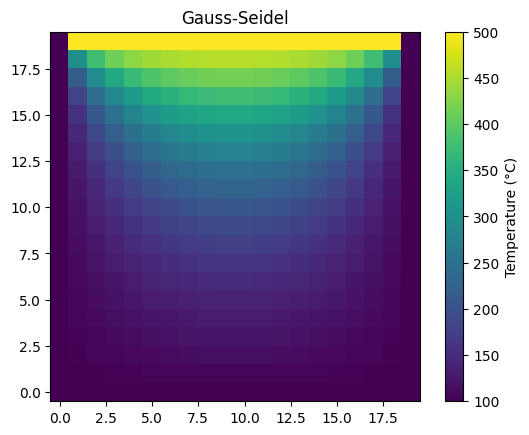

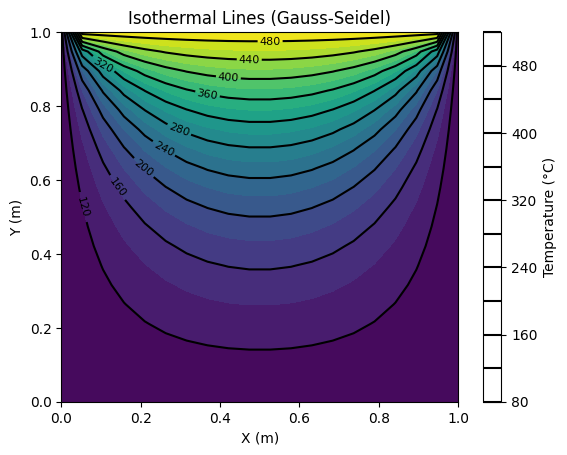

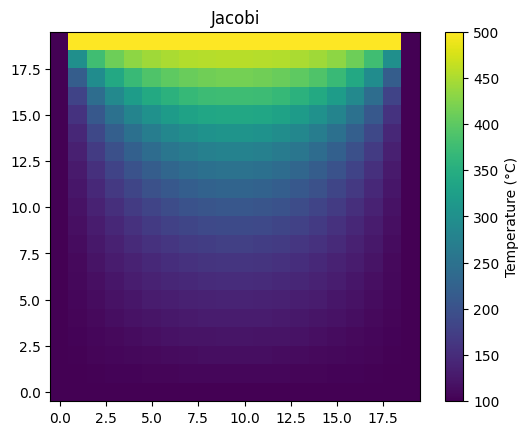

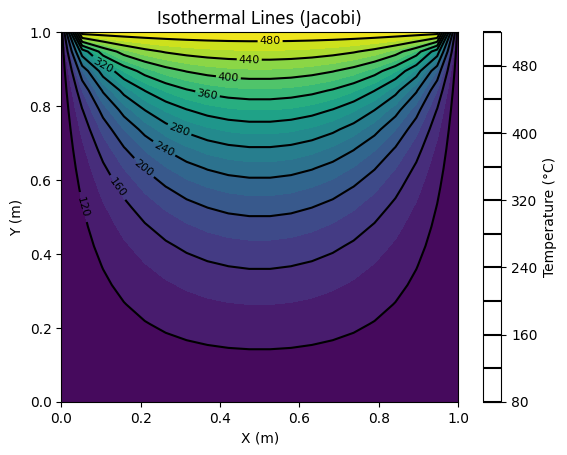

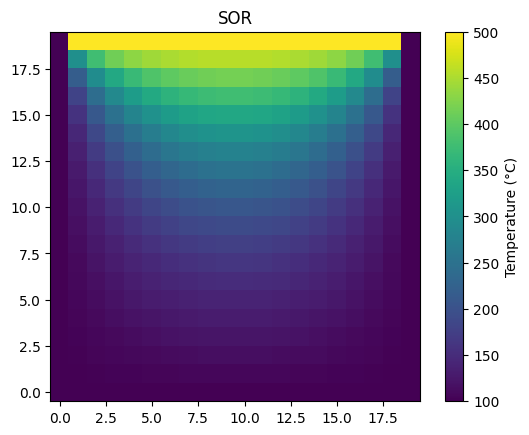

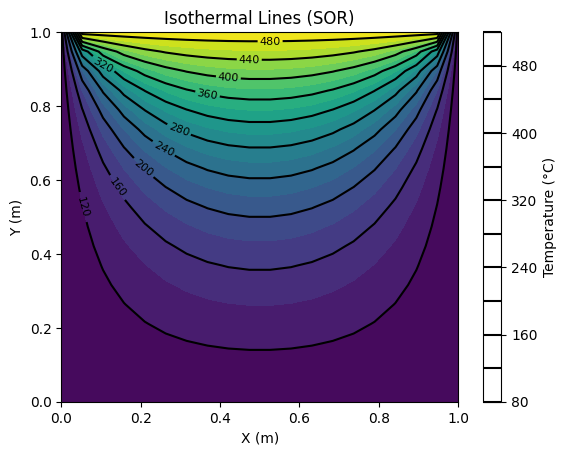


========== ANALYTICAL ==========

[[100.   511.07 500.42 495.84 504.1  498.08 499.27 502.44 497.51 501.03
  501.03 497.51 502.44 499.27 498.08 504.1  495.84 500.42 511.07 100.  ]
 [100.   298.79 379.49 414.34 432.55 443.22 449.86 454.02 456.48 457.63
  457.63 456.48 454.02 449.86 443.22 432.55 414.34 379.49 298.79 100.  ]
 [100.   215.66 295.15 342.89 371.9  390.22 402.07 409.68 414.24 416.38
  416.38 414.24 409.68 402.07 390.22 371.9  342.89 295.15 215.66 100.  ]
 [100.   178.38 242.56 289.1  321.31 343.38 358.38 368.3  374.36 377.23
  377.23 374.36 368.3  358.38 343.38 321.31 289.1  242.56 178.38 100.  ]
 [100.   157.73 208.69 249.63 280.66 303.41 319.63 330.7  337.6  340.9
  340.9  337.6  330.7  319.63 303.41 280.66 249.63 208.69 157.73 100.  ]
 [100.   144.59 185.46 220.26 248.29 269.92 285.96 297.22 304.37 307.84
  307.84 304.37 297.22 285.96 269.92 248.29 220.26 185.46 144.59 100.  ]
 [100.   135.44 168.61 197.86 222.37 242.   257.02 267.82 274.79 278.2
  278.2  274.79 267.82 25

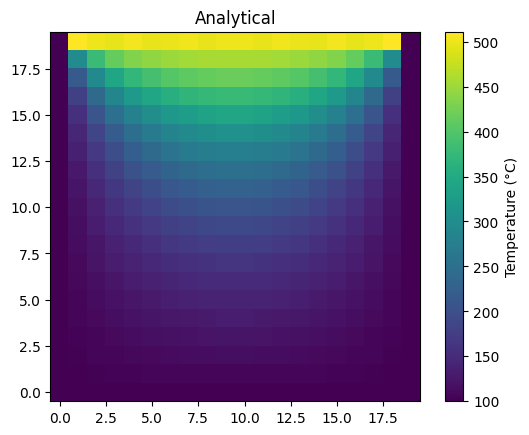

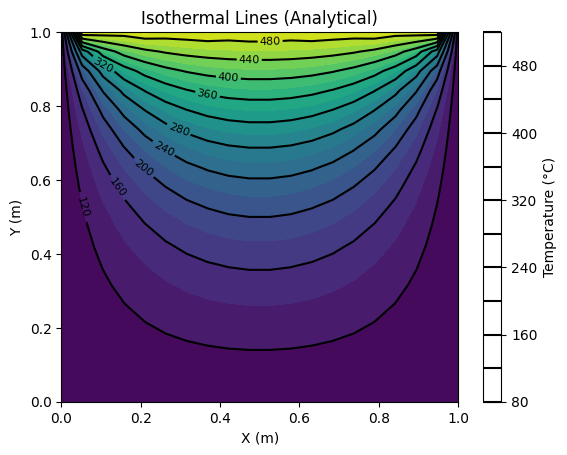


========== ERROR (GAUSS-SEIDEL ONLY) ==========

Max Error = 11.0731
Max % Error = 2.1666 %


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#USER INPUT

nx = int(input("Enter grid points in x : "))
ny = int(input("Enter grid points in y : "))

Lx = float(input("Enter plate length in x-direction (m): "))
Ly = float(input("Enter plate length in y-direction (m): "))

print("\nBoundary Type: 1 = Fixed Temperature, 2 = Convection")

bottom_type = int(input("Bottom Boundary: "))
top_type    = int(input("Top Boundary: "))
left_type   = int(input("Left Boundary: "))
right_type  = int(input("Right Boundary: "))

k = float(input("\nEnter thermal conductivity k: "))

#######################333
def get_bc(side, btype):
    if btype == 1:
        return {"type":1, "T": float(input(f"{side} Temperature: "))}
    else:
        return {"type":2,
                "h": float(input(f"h_{side}: ")),
                "Tinf": float(input(f"T_inf_{side}: "))}

bottom = get_bc("Bottom", bottom_type)
top    = get_bc("Top", top_type)
left   = get_bc("Left", left_type)
right  = get_bc("Right", right_type)

# GRID SIZE
dx = Lx/(nx-1)
dy = Ly/(ny-1)

print("\nGrid size:")
print("dx =", dx)
print("dy =", dy)

#boundary condition
def apply_bc(T):

    if bottom["type"] == 1:
        T[0,:] = bottom["T"]
    else:
        for j in range(1,nx-1):
            T[0,j] = (T[1,j] + (bottom["h"]*dy/k)*bottom["Tinf"]) / (1 + (bottom["h"]*dy/k))

    if top["type"] == 1:
        T[-1,:] = top["T"]
    else:
        for j in range(1,nx-1):
            T[-1,j] = (T[-2,j] + (top["h"]*dy/k)*top["Tinf"]) / (1 + (top["h"]*dy/k))

    if left["type"] == 1:
        T[:,0] = left["T"]
    else:
        for i in range(1,ny-1):
            T[i,0] = (T[i,1] + (left["h"]*dx/k)*left["Tinf"]) / (1 + (left["h"]*dx/k))

    if right["type"] == 1:
        T[:,-1] = right["T"]
    else:
        for i in range(1,ny-1):
            T[i,-1] = (T[i,-2] + (right["h"]*dx/k)*right["Tinf"]) / (1 + (right["h"]*dx/k))

    return T

########3
max_iter = 5000
tol = 0.01


def solve(method="GS", w=1.5):

    T = np.ones((ny,nx))*100

    for it in range(max_iter):
        T_old = T.copy()

        for i in range(1,ny-1):
            for j in range(1,nx-1):

                if method == "Jacobi":
                    T[i,j] = 0.25*(T_old[i+1,j]+T_old[i-1,j]+T_old[i,j+1]+T_old[i,j-1])

                elif method == "SOR":
                    T_gs = 0.25*(T[i+1,j]+T[i-1,j]+T[i,j+1]+T[i,j-1])
                    T[i,j] = (1-w)*T[i,j] + w*T_gs

                else:  # Gauss-Seidel
                    T[i,j] = 0.25*(T[i+1,j]+T[i-1,j]+T[i,j+1]+T[i,j-1])

        T = apply_bc(T)

        if np.max(np.abs(T-T_old)) < tol:
            print(f"\n{method} converged in {it} iterations")
            break

    return T

# call
T  = solve("GS")
Tj = solve("Jacobi")
Ts = solve("SOR")

# output
print("\n========== GAUSS-SEIDEL ==========\n", np.round(np.flipud(T),2))
print("\n========== JACOBI ==========\n", np.round(np.flipud(Tj),2))
print("\n========== SOR ==========\n", np.round(np.flipud(Ts),2))

#
x = np.linspace(0, Lx, nx)
y = np.linspace(0, Ly, ny)
X, Y = np.meshgrid(x, y)

#plot
def plot_all(T, title):

    plt.imshow(T, origin='lower')
    plt.colorbar(label="Temperature (°C)")
    plt.title(title)
    plt.show()

    plt.figure()
    plt.contourf(X, Y, T, levels=20)
    c = plt.contour(X, Y, T, levels=10, colors='black')
    plt.clabel(c, fontsize=8)

    plt.colorbar(label="Temperature (°C)")
    plt.title(f"Isothermal Lines ({title})")
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")
    plt.show()

plot_all(T,  "Gauss-Seidel")
plot_all(Tj, "Jacobi")
plot_all(Ts, "SOR")

# error + analitical
if bottom_type==1 and top_type==1 and left_type==1 and right_type==1:

    if left["T"] != bottom["T"] or right["T"] != bottom["T"]:
        print("\nAnalytical solution NOT valid for these boundary values")

    else:

        T_bottom = bottom["T"]
        T_top    = top["T"]

        def analytical_temp(x,y):
            theta = 0
            deltaT = T_top - T_bottom

            for n in range(1,100,2):
                term = (4*deltaT)/(n*np.pi)
                term *= np.sinh(n*np.pi*y/Lx)/np.sinh(n*np.pi*Ly/Lx)
                term *= np.sin(n*np.pi*x/Lx)
                theta += term

            return T_bottom + theta

        T_an = np.zeros((ny,nx))

        for i in range(ny):
            for j in range(nx):
                T_an[i,j] = analytical_temp(x[j],y[i])

        print("\n========== ANALYTICAL ==========\n")
        print(np.round(np.flipud(T_an),2))

        plot_all(T_an, "Analytical")

        #
        print("\n========== ERROR (GAUSS-SEIDEL ONLY) ==========\n")

        max_error = np.max(np.abs(T - T_an))

        percent_error = np.max(
            np.abs((T - T_an) / (T_an + 1e-6))
        ) * 100

        print(f"Max Error = {max_error:.4f}")
        print(f"Max % Error = {percent_error:.4f} %")

else:
    print("\nAnalytical solution not applicable for convection case")